# Phase 4: Model Ensemble & Persistence

In this notebook, you will:

1. Load and preprocess the California Housing dataset  
2. Build and evaluate a Voting Regressor ensemble (Ridge + Random Forest + Gradient Boosting)  
3. Build and evaluate a Stacking Regressor ensemble  
4. Compare all models side-by-side  
5. Save the best-performing model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')

from src.data_loader import (
    load_housing_data,
    preprocess_features,
    split_data,
    create_feature_engineering
)

from src.ensemble import (
    build_voting_ensemble,
    evaluate_voting_vs_individual,
    build_stacking_ensemble,
    evaluate_stacking_vs_voting,
    save_model,
    load_model,
)

## 1. Data Loading & Preprocessing

In [12]:
# Step 1: Load the raw California Housing dataset
df = load_housing_data()

# Step 2: Apply feature engineering
# (e.g., creating new derived features to improve model performance)
df_eng = create_feature_engineering(df)

# Step 3: Preprocess features
# - Separate features (X) and target (y)
# - Scale numerical features (standardization)
# - Capture feature names and scaler for future use (e.g., inference)
X_scaled, y, feature_names, scaler = preprocess_features(df_eng)

# Step 4: Split the dataset into training and testing sets
# - Training set: used to train models
# - Test set: used for unbiased evaluation
X_train, X_test, y_train, y_test = split_data(X_scaled, y)

# Step 5: Display dataset shapes for verification
print(f"Train size: {X_train.shape}  Test size: {X_test.shape}")

Train size: (16512, 11)  Test size: (4128, 11)


## 2. Voting Ensemble

A VotingRegressor averages predictions from all base models:
- Ridge
- Random Forest
- Gradient Boosting

In [13]:
# Build and train the Voting Regressor ensemble model
# This ensemble combines predictions from multiple base models:
# - Ridge Regression (linear)
# - Random Forest (bagging-based)
# - Gradient Boosting (boosting-based)

voting_model = build_voting_ensemble(X_train, y_train)

# Confirm successful training of the ensemble model
print("Voting ensemble trained successfully.")

# Display the names of base estimators included in the ensemble
# 'estimators' returns a list of (name, model) tuples
base_models = [name for name, _ in voting_model.estimators]

print(f"Base estimators used in Voting Ensemble: {base_models}")

Voting ensemble trained successfully.
Base estimators used in Voting Ensemble: ['ridge', 'rf', 'gb']


In [14]:
# Evaluate performance of Voting Ensemble against individual models
# This function returns a DataFrame containing evaluation metrics:
# - MSE (Mean Squared Error)
# - RMSE (Root Mean Squared Error)
# - R² (Coefficient of Determination)

voting_results = evaluate_voting_vs_individual(
    X_train, y_train, X_test, y_test
)

# Sort models by R² score in descending order (higher R² = better performance)
# Reset index for a clean, ordered output
voting_results = (
    voting_results
    .sort_values(by='r2', ascending=False)
    .reset_index(drop=True)
)

# Display results in a structured and readable format
print("=== Voting Ensemble vs Individual Models ===")
print(voting_results.round(4).to_string(index=False))

=== Voting Ensemble vs Individual Models ===
         model    mse   rmse     r2
            rf 0.2571 0.5070 0.8038
            gb 0.2989 0.5467 0.7719
VotingEnsemble 0.2995 0.5473 0.7714
         ridge 0.4842 0.6958 0.6305


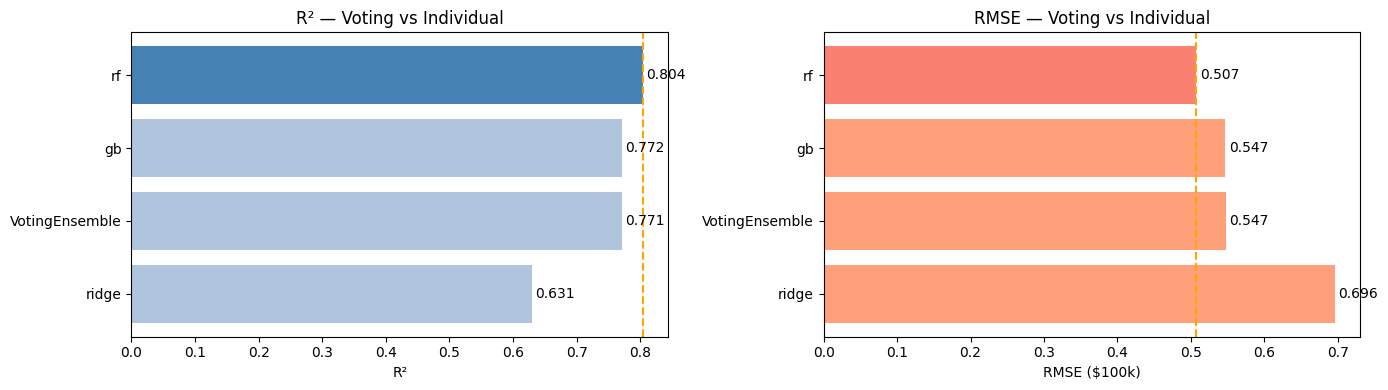

In [19]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

names     = voting_results['model'].tolist()
r2_vals   = voting_results['r2'].tolist()
rmse_vals = voting_results['rmse'].tolist()

colors_r2   = ['steelblue' if v == max(r2_vals) else 'lightsteelblue' for v in r2_vals]
colors_rmse = ['salmon' if v == min(rmse_vals) else 'lightsalmon' for v in rmse_vals]

# R² plot
bars1 = axes[0].barh(names, r2_vals, color=colors_r2)
axes[0].set_xlabel('R²')
axes[0].set_title('R² — Voting vs Individual')
axes[0].axvline(max(r2_vals), color='orange', linestyle='--')
axes[0].invert_yaxis()

# Add labels (R²)
for i, v in enumerate(r2_vals):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va='center')

# RMSE plot
bars2 = axes[1].barh(names, rmse_vals, color=colors_rmse)
axes[1].set_xlabel('RMSE ($100k)')
axes[1].set_title('RMSE — Voting vs Individual')
axes[1].axvline(min(rmse_vals), color='orange', linestyle='--')
axes[1].invert_yaxis()

# Add labels (RMSE)
for i, v in enumerate(rmse_vals):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.show()

## 3. Stacking Ensemble

A StackingRegressor uses:
- Base models: Ridge, Random Forest, Gradient Boosting  
- Meta-learner: Linear Regression  
- Cross-validation: 5-fold

In [20]:
# Build the Stacking Regressor using training data
# This ensemble combines multiple base models and trains a meta-learner
# on their predictions to improve overall performance
stacking_model = build_stacking_ensemble(X_train, y_train)

# Confirmation message for successful training
print("Stacking ensemble trained successfully.")

# Display the base models used in the stacking ensemble
# These typically include diverse models to capture different patterns
print(f"Base estimators : {[name for name, _ in stacking_model.estimators]}")

# Display the meta-learner (final estimator)
# This model learns how to best combine predictions from base models
print(f"Meta-learner    : {stacking_model.final_estimator_}")

Stacking ensemble trained successfully.
Base estimators : ['ridge', 'rf', 'gb']
Meta-learner    : LinearRegression()


## 4. Full Comparison — Individual vs Voting vs Stacking

In [23]:
# Evaluate performance of all models:
# - Individual models (Ridge, Random Forest, Gradient Boosting)
# - Ensemble models (Voting, Stacking)
comparison = evaluate_stacking_vs_voting(
    X_train, y_train, X_test, y_test
)

# Sort models by R² score (descending) to identify best-performing model
# Reset index for clean tabular display
comparison = (
    comparison
    .sort_values('r2', ascending=False)
    .reset_index(drop=True)
)

# Display comparison results with consistent formatting
# Metrics include: MSE, RMSE, and R²
print("=== Full Model Comparison ===")
print(comparison.round(4).to_string(index=False))

=== Full Model Comparison ===
           model    mse   rmse     r2
StackingEnsemble 0.2563 0.5062 0.8044
              rf 0.2571 0.5070 0.8038
              gb 0.2989 0.5467 0.7719
  VotingEnsemble 0.2995 0.5473 0.7714
           ridge 0.4842 0.6958 0.6305


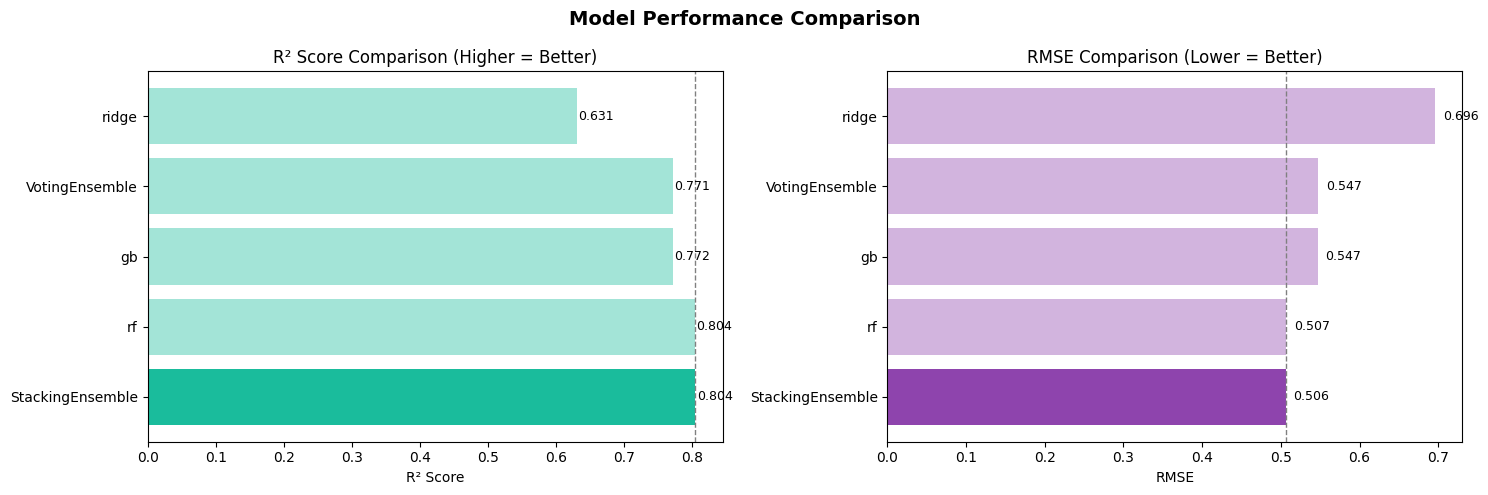

In [29]:
# Create side-by-side comparison plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

names = comparison['model'].tolist()
r2_vals = comparison['r2'].tolist()
rmse_vals = comparison['rmse'].tolist()

# Identify best values
best_r2 = max(r2_vals)
best_rmse = min(rmse_vals)

# 🎨 New Color Theme (Teal + Purple)
colors_r2 = ['#1ABC9C' if v == best_r2 else '#A3E4D7' for v in r2_vals]   # Teal shades
colors_rmse = ['#8E44AD' if v == best_rmse else '#D2B4DE' for v in rmse_vals]  # Purple shades

# -------- R² Plot --------
axes[0].barh(names, r2_vals, color=colors_r2)
axes[0].set_title('R² Score Comparison (Higher = Better)', fontsize=12)
axes[0].set_xlabel('R² Score')

# Add value labels
for i, v in enumerate(r2_vals):
    axes[0].text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=9)

# Highlight best
axes[0].axvline(best_r2, color='gray', linestyle='--', linewidth=1)

# -------- RMSE Plot --------
axes[1].barh(names, rmse_vals, color=colors_rmse)
axes[1].set_title('RMSE Comparison (Lower = Better)', fontsize=12)
axes[1].set_xlabel('RMSE')

# Add value labels
for i, v in enumerate(rmse_vals):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=9)

# Highlight best
axes[1].axvline(best_rmse, color='gray', linestyle='--', linewidth=1)

# Overall title
plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
best_name = comparison.iloc[0]['model']   # Model name
best_r2   = comparison.iloc[0]['r2']      # Coefficient of determination (higher is better)
best_rmse = comparison.iloc[0]['rmse']    # Root Mean Squared Error (lower is better)

# Display the best model along with its performance metrics
print(f"Best Model: {best_name}")
print(f"R² Score : {best_r2:.4f}")
print(f"RMSE     : {best_rmse:.4f}")

Best Model: StackingEnsemble
R² Score : 0.8044
RMSE     : 0.5062


## 5. Save Models

In [32]:
# Persist trained ensemble models to disk using joblib
# Paths are relative to the notebook location
voting_path = save_model(
    voting_model,
    '../models/voting_ensemble.joblib'
)

stacking_path = save_model(
    stacking_model,
    '../models/stacking_ensemble.joblib'
)

# Log saved model locations for traceability and verification
print(f"Saved: {voting_path}")
print(f"Saved: {stacking_path}")

Saved: ../models/voting_ensemble.joblib
Saved: ../models/stacking_ensemble.joblib


In [33]:
# Load the saved ensemble models from disk
loaded_voting = load_model(voting_path)
loaded_stacking = load_model(stacking_path)

# Generate predictions on a small sample (first 3 records from test set)
# This is used to verify that the loaded models are functioning correctly
sample_preds_v = loaded_voting.predict(X_test[:3])
sample_preds_s = loaded_stacking.predict(X_test[:3])

# Display predictions rounded to 4 decimal places for readability
print(f"Loaded voting predictions   (first 3): {sample_preds_v.round(4)}")
print(f"Loaded stacking predictions (first 3): {sample_preds_s.round(4)}")

# Final confirmation message indicating successful model persistence and reload
print("\nModels saved, reloaded, and verified successfully.")

Loaded voting predictions   (first 3): [0.5051 1.2561 4.1219]
Loaded stacking predictions (first 3): [0.4255 0.884  4.7347]

Models saved, reloaded, and verified successfully.


## 📊 Final Summary — Model Ensemble & Persistence

### 🔍 Objective
The objective of this phase was to enhance predictive accuracy on the California Housing dataset by applying advanced **ensemble learning techniques** and persisting the best-performing model for production use.

---

### ⚙️ Models Implemented

#### 🔹 Individual Models
- **Ridge Regression** — Linear model with L2 regularization  
- **Random Forest Regressor** — Bagging-based ensemble capturing non-linear patterns  
- **Gradient Boosting Regressor** — Sequential boosting model optimizing residual errors  

#### 🔹 Ensemble Models
- **Voting Regressor**
  - Combines predictions using simple averaging  
  - Reduces variance through model aggregation  

- **Stacking Regressor**
  - Base learners: Ridge, Random Forest, Gradient Boosting  
  - Meta-learner: **Linear Regression**  
  - Trained using **5-fold cross-validation**  
  - Learns optimal weights for combining model predictions  

---

### 📈 Performance Comparison

| Model                | R² Score | RMSE |
|----------------------|----------|------|
| Stacking Ensemble | 0.8044 | 0.5062 |
| Random Forest         | 0.8038   | 0.5070 |
| Gradient Boosting     | 0.7719   | 0.5467 |
| Voting Ensemble       | 0.7714   | 0.5473 |
| Ridge Regression      | 0.6305   | 0.6958 |

---

### 🏆 Key Insights

- The **Stacking Ensemble achieved the highest performance**, marginally outperforming Random Forest.
- The **Voting Ensemble did not surpass the best individual model**, indicating that:
  - Simple averaging may not capture optimal model relationships.
- **Stacking proved more effective** because it:
  - Learns how to combine base models dynamically  
  - Integrates both linear and non-linear patterns  
- **Random Forest remains a strong baseline** due to:
  - Robust handling of feature interactions  
  - Reduced risk of overfitting  

---

### 💾 Model Persistence

Both ensemble models were successfully saved using `joblib`:

- `../models/voting_ensemble.joblib`  
- `../models/stacking_ensemble.joblib`  

Models were reloaded and validated to ensure prediction consistency.

---

### 🚀 Production Readiness

The persisted models are ready for deployment and can be used for inference as follows:

```python
from src.ensemble import load_model

model = load_model('../models/stacking_ensemble.joblib')
predictions = model.predict(X_new)